## Reproductible fitting for the `jmstate` package

In [ ]:
%pip install -q jmstate==0.13.2 pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from jmstate import MultiStateJointModel

pd.set_option("display.float_format", "{:.3f}".format)

In [3]:
torch.manual_seed(42)


TAU = 7.5


def regression(t: torch.Tensor, psi: torch.Tensor):
    b, w1, w2 = psi.chunk(3, dim=-1)  # Extract relevant terms

    # psi has shape (n_chains, n_individuals, n_repetitions)
    return (b + w1 * t + (w2 - w1) * (t > TAU) * (t - TAU)).unsqueeze(-1)


def link(t: torch.Tensor, psi: torch.Tensor):
    b, w1, w2 = psi.chunk(3, dim=-1)

    diff = (w2 - w1) * (t > TAU)
    val = b + w1 * t + diff * (t - TAU)
    der = w1 + diff
    return torch.cat([val.unsqueeze(-1), der.unsqueeze(-1)], dim=-1)


def random_far_apart(
    n: int, m: int, a: torch.Tensor, b: torch.Tensor, min_dist: torch.Tensor
):
    L_free = (b - a) - (m - 1) * min_dist

    y = torch.rand(n, m) * L_free
    y, _ = torch.sort(y, dim=1)

    gap_offset = torch.arange(m) * min_dist

    return a + y + gap_offset


def gen_data(n: int, m: int, true_model: MultiStateJointModel):
    # Censoring times
    c = torch.rand(n, 1) * 5 + 10

    # Covariates
    x = torch.randn(n, 1)

    # Latent and noise distributions
    Q_dist = MultivariateNormal(torch.zeros(Q.size(0)), Q)
    R_dist = MultivariateNormal(torch.zeros(R.size(0)), R)

    # Individual effects
    b = Q_dist.sample((n,))
    psi = true_model.design.indiv_params_fn(gamma, x, b)

    # Generates random evaluations points with a minimum distance
    a = torch.zeros((n, 1))
    b = torch.full((n, 1), 15)
    t = random_far_apart(n, m, a, b, 0.7 * b / m)

    # Defines initial state for individuals
    trajectories_init = [[(0.0, 0)] for _ in range(n)]

    # Samples trajectories
    sample_data = SampleData(x, trajectories_init, psi)
    trajectories = true_model.sample_trajectories(sample_data, c)

    # Samples longitudinal values
    y = design.regression_fn(t, psi)
    y += R_dist.sample(y.shape[:2])

    # Censors longitudinal measurements exceeding censoring times
    y[t > c] = torch.nan

    return x, t, y, trajectories, c

In [4]:
from jmstate.types import ModelDesign

# Survival model specification
surv_fns = {(0, 1): link, (0, 2): link, (1, 2): link}

# Model design gathers regression, link and hazard functions
design = ModelDesign(lambda pop, x, b: pop + b, regression, surv_fns)

In [5]:
from jmstate.types import ModelParameters, PrecisionParameters
from jmstate.functions.base_hazards import Exponential

# Using the notation from the paper instead of the ones of the package

# Gaussian means
gamma = torch.tensor([2.5, -1.3, 0.2])

# Covariance matrices
Q = torch.diag(torch.tensor([0.6, 0.2, 0.3]))
R = torch.tensor([[1.7]])

# Base hazard functions
base_hazards = {
    (0, 1): Exponential(1e-3, frozen=True),
    (0, 2): Exponential(1e-4, frozen=True),
    (1, 2): Exponential(1e-4, frozen=True),
}

# Link parameters
alphas = {
    (0, 1): torch.tensor([-0.5, -1.0]),
    (0, 2): torch.tensor([-1.0, -0.5]),
    (1, 2): torch.tensor([-1.0, 0.0]),
}

# Covariate parameters
betas = {
    (0, 1): torch.tensor([-1.3]),
    (0, 2): torch.tensor([-0.9]),
    (1, 2): torch.tensor([-0.7]),
}

# Instance declaration
true_parameters = ModelParameters(
    gamma,
    PrecisionParameters.from_covariance(Q, "diag"),
    PrecisionParameters.from_covariance(R, "spherical"),
    base_hazards,
    alphas,
    betas,
)

In [6]:
from jmstate.types import ModelData, SampleData
from torch.distributions import MultivariateNormal

# Declare the true underlying model
true_model = MultiStateJointModel(design, true_parameters)

# Generate data
data = ModelData(*gen_data(1000, 20, true_model))

In [7]:
from jmstate.utils import build_buckets

buckets = build_buckets(data.trajectories)
print({key: val.idxs.numel() for key, val in buckets.items()})

{(0, 1): 300, (0, 2): 316, (1, 2): 216}


In [8]:
# Declares initial parameters; zero mean and unit variance
def init_params_correct():
    return ModelParameters(
        torch.zeros_like(gamma),
        PrecisionParameters.from_covariance(torch.eye(Q.size(0)), "diag"),
        PrecisionParameters.from_covariance(torch.eye(R.size(0)), "spherical"),
        base_hazards,
        {k: torch.zeros_like(v) for k, v in alphas.items()},
        {k: torch.zeros_like(v) for k, v in betas.items()},
    )


# Misspecified parameters (too few)
def init_params_less():
    alpha_shared = torch.nn.Parameter(torch.zeros(2))
    return ModelParameters(
        torch.zeros_like(gamma),
        PrecisionParameters.from_covariance(torch.eye(Q.size(0)), "diag"),
        PrecisionParameters.from_covariance(torch.eye(R.size(0)), "spherical"),
        base_hazards,
        {k: alpha_shared for k, v in alphas.items()},
        {k: torch.zeros_like(v) for k, v in betas.items()},
    )


# Misspecified parameters (too many)
def init_params_more():
    return ModelParameters(
        torch.zeros_like(gamma),
        PrecisionParameters.from_covariance(torch.eye(Q.size(0)), "full"),
        PrecisionParameters.from_covariance(torch.eye(R.size(0)), "spherical"),
        base_hazards,
        {k: torch.zeros_like(v) for k, v in alphas.items()},
        {k: torch.zeros_like(v) for k, v in betas.items()},
    )


In [9]:
# Declares initial model
params = init_params_correct()
optimizer = torch.optim.Adam(params.parameters(), lr=0.5, amsgrad=True)
model = MultiStateJointModel(design, params, optimizer)

# Runs optimization process
model.fit(data)

Computing FIM and Model Selection Criteria: 100%|██████████| 100/100 [00:10<00:00,  9.18it/s]


,design,ModelDesign(i...287160DBD80>})
,params,ModelParamete... of size 1] ))
,optimizer,Adam ( Parame...ght_decay: 0 )
,n_quad,32
,n_bisect,32
,n_chains,5
,init_step_size,0.1
,adapt_rate,0.01
,target_accept_rate,0.234
,n_warmup,100
,n_subsample,10


╭─────────────────────────────────────── Model Summary ───────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓ │
│ ┃ Parameter name       ┃ Value  ┃ Standard Error ┃ z-value ┃ p-value ┃ Significance level ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩ │
│ │ pop_params[0]        │ 2.443  │     0.034      │ 72.283  │  0.000  │        ***         │ │
│ │ pop_params[1]        │ -1.280 │     0.014      │ 93.951  │  0.000  │        ***         │ │
│ │ pop_params[2]        │ 0.222  │     0.019      │ 11.732  │  0.000  │        ***         │ │
│ │ random_prec.flat[0]  │ 0.273  │     0.041      │  6.702  │  0.000  │        ***         │ │
│ │ random_prec.flat[1]  │ 0.820  │     0.026      │ 31.261  │  0.000  │        ***         │ │
│ │ random_prec.flat[2]  │ 0.635  │     0.029      │ 22.101  │  0.000  │        ***         │ │
│ │ noise_prec.flat[0]   │ -0.281 │     0.006      │ 45.894  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 1)[0] │ -0.556 │     0.020      │ 27.543  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 1)[1] │ -0.909 │     0.085      │ 10.687  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 2)[0] │ -0.998 │     0.016      │ 62.320  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 2)[1] │ -0.559 │     0.081      │  6.893  │  0.000  │        ***         │ │
│ │ link_coefs.(1, 2)[0] │ -1.003 │     0.018      │ 56.384  │  0.000  │        ***         │ │
│ │ link_coefs.(1, 2)[1] │ -0.167 │     0.093      │  1.792  │  0.073  │         .          │ │
│ │ x_coefs.(0, 1)[0]    │ -1.190 │     0.063      │ 19.003  │  0.000  │        ***         │ │
│ │ x_coefs.(0, 2)[0]    │ -0.980 │     0.070      │ 14.043  │  0.000  │        ***         │ │
│ │ x_coefs.(1, 2)[0]    │ -0.553 │     0.095      │  5.825  │  0.000  │        ***         │ │
│ └──────────────────────┴────────┴────────────────┴─────────┴─────────┴────────────────────┘ │
│ ─────────────────────────────────────────────────────────────────────────────────────────── │
│ Log-likelihood: -33057.363                                                                  │
│ AIC: 66146.725                                                                              │
│ BIC: 66227.554                                                                              │
│ ─────────────────────────────────────────────────────────────────────────────────────────── │
╰─────────────────────────────────────────────────────────────────────────────────────────────╯

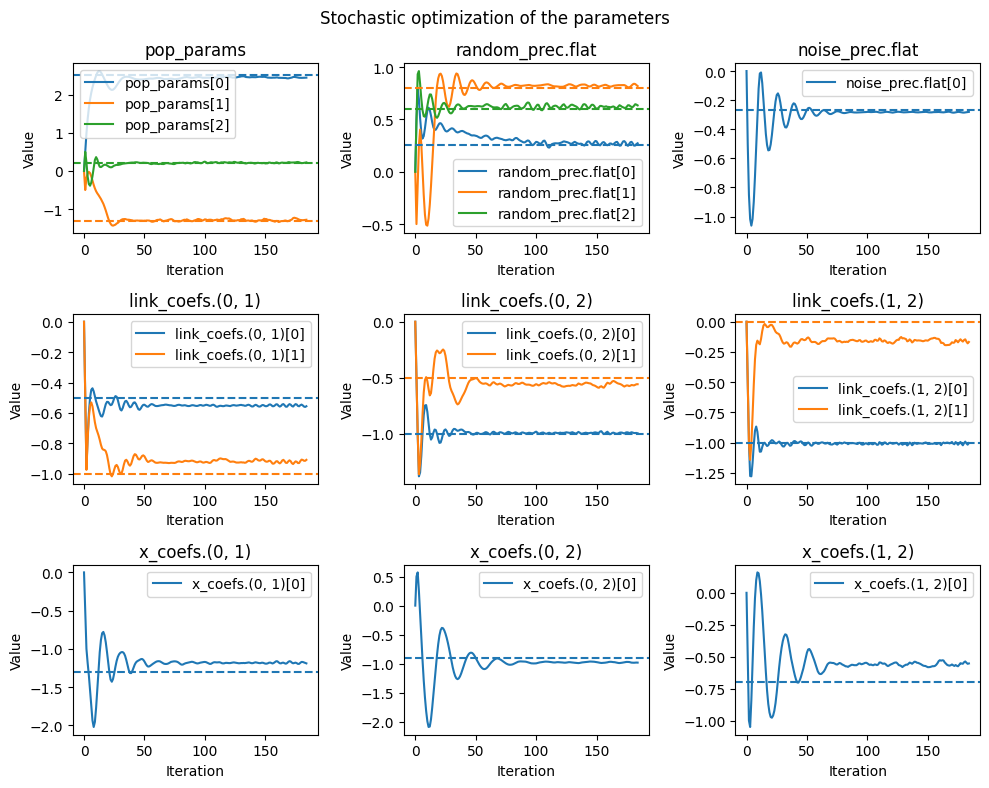

In [10]:
from jmstate.utils import plot_params_history, summary

# Prints relevant information
summary(model)

fig, axes = plot_params_history(model)

# Add true parameters
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for ax, param in zip(list(axes), true_parameters.parameters(), strict=False):
    for i, p in enumerate(param):
        ax.axhline(y=p.detach(), c=colors[i], linestyle="--")

plt.savefig("../figures/stochastic-optimization.pdf")
plt.show()

In [11]:
from torch.nn.utils import parameters_to_vector
from tqdm import trange


def get_vector_and_scores(parameters_factory, data):
    parameters = parameters_factory()
    optimizer = torch.optim.Adam(parameters.parameters(), lr=0.5, amsgrad=True)
    model = MultiStateJointModel(design, parameters, optimizer, verbose=False).fit(data)

    return parameters_to_vector(model.parameters()), model.aic_, model.bic_


# Define competing models
parameters_factories = {
    "correct": init_params_correct,
    "less": init_params_less,
    "more": init_params_more,
}
n_redo = 100

# Storage for results
all_results = defaultdict(list)

for _ in trange(n_redo):
    # Generate new data for this redo
    data = ModelData(*gen_data(1000, 20, true_model))

    for name, factory in parameters_factories.items():
        vec, aic, bic = get_vector_and_scores(factory, data)
        all_results[name].append({"vec": vec, "aic": aic, "bic": bic})

# Extract Param vectors, AICs, and BICs for analysis
vecs = {name: [r["vec"] for r in all_results[name]] for name in parameters_factories}
aics = {name: [r["aic"] for r in all_results[name]] for name in parameters_factories}
bics = {name: [r["bic"] for r in all_results[name]] for name in parameters_factories}


100%|██████████| 100/100 [2:21:18<00:00, 84.79s/it] 


In [14]:
true_params_vec = parameters_to_vector(true_parameters.parameters()).detach().numpy()

# Compute statistics
stacked_params = torch.stack(vecs["correct"]).detach().numpy()
bias = stacked_params.mean(axis=0) - true_params_vec
std = stacked_params.std(axis=0)
rmse = np.sqrt(std**2 + bias**2)

# Put as a dict
convergence = {
    "True value": true_params_vec,
    "Bias": bias,
    "Std deviation": std,
    "RMSE": rmse,
}

# Set names for the dataframe
named_parameters_dict = dict(true_parameters.named_parameters())
index = [
    f"{name}[{j}]"
    for name, param in named_parameters_dict.items()
    for j in range(param.numel())
]

# Create dataframe
convergence_df = pd.DataFrame(convergence, index=index)
convergence_df.to_csv("../results/convergence-results.csv")

print(convergence_df)

                      True value   Bias  Std deviation  RMSE
pop_params[0]              2.500 -0.004          0.038 0.038
pop_params[1]             -1.300  0.000          0.033 0.033
pop_params[2]              0.200 -0.000          0.025 0.025
random_prec.flat[0]        0.255 -0.002          0.040 0.040
random_prec.flat[1]        0.805 -0.004          0.025 0.025
random_prec.flat[2]        0.602 -0.002          0.032 0.032
noise_prec.flat[0]        -0.265  0.000          0.007 0.007
link_coefs.(0, 1)[0]      -0.500 -0.004          0.023 0.023
link_coefs.(0, 1)[1]      -1.000  0.010          0.086 0.087
link_coefs.(0, 2)[0]      -1.000 -0.007          0.015 0.016
link_coefs.(0, 2)[1]      -0.500  0.027          0.073 0.078
link_coefs.(1, 2)[0]      -1.000  0.001          0.019 0.019
link_coefs.(1, 2)[1]       0.000  0.003          0.091 0.091
x_coefs.(0, 1)[0]         -1.300 -0.004          0.061 0.061
x_coefs.(0, 2)[0]         -0.900 -0.003          0.065 0.065
x_coefs.(1, 2)[0]       

In [15]:
# Build a dataframe where rows = redo, columns = model
df_aic = pd.DataFrame(aics)
df_bic = pd.DataFrame(bics)

# For each redo, find which model has the minimum
winners_aic = df_aic.idxmin(axis=1)
winners_bic = df_bic.idxmin(axis=1)

# Count how many times each model wins
counts_df = (
    pd.DataFrame(
        {
            "AIC": winners_aic.value_counts(),
            "BIC": winners_bic.value_counts(),
        }
    )
    .fillna(0)
    .astype(int)
)
counts_df.to_csv("../results/selection-results.csv")

print(counts_df)

         AIC  BIC
correct   69   93
more      31    7
